# Closed-form RNNs for $C_n\times C_n$

This notebook constructs a quadratic RNN whose recurrent state realizes translation on the finite square torus

$$G=C_n\times C_n.$$

A vector $x\in\mathbb R^{n^2}$ is identified with a scalar signal $x:G\to\mathbb R$. Because this group is abelian, every irreducible representation is one-dimensional. This makes the construction the simplest two-dimensional counterpart of the discrete-$SE(2)$ notebook: it retains the same encoding, weight, rollout, reconstruction, trajectory, and tuning diagnostics, but has no orientation coordinate or semidirect-product rotation.

We first verify an exact all-irrep model on a small group, then use a power-selected Fourier truncation for an approximate $n=50$ spatial experiment.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

project_root = next(
    parent
    for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "src").is_dir()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.cnxcn_geometry import (
    TRACK_COLOR,
    center_errors,
    decode_spatial_argmax,
    gaussian_bump,
    make_momentum_motion_sequence,
    plot_grid_scalar,
    plot_grid_trajectory,
    signal_to_grid,
    transformed_center,
)
from src.finite_group_rnn import (
    build_finite_group_rnn,
    hidden_width,
    probe_hidden_states as hidden_tuning_over_group,
    random_invertible_encoding,
    rollout,
)
from src.groups import ProductCyclicGroup
from src.neural_manifold import (
    analyze_module_orbits,
    build_module_orbits,
    combine_module_orbits,
    coordinate_colors,
    fixed_point_embedding,
    plot_manifold_analysis,
)

np.set_printoptions(precision=3, suppress=True)

## 1. Group, action, and Fourier structure

Write $g=(a,b)$ with $a,b\in C_n$. The group law is componentwise addition,

$$(a,b)(c,d)=(a+c,b+d)\pmod n,$$

and the regular left action is

$$(g\cdot x)[h]=x[g^{-1}h].$$

Equivalently, $g$ translates the $n\times n$ signal on a periodic square grid. The irreps are one-dimensional characters, corresponding to the familiar Fourier modes

$$\rho_{k,\ell}(a,b)=\exp\left[2\pi i\left(\frac{ka}{n}+\frac{\ell b}{n}\right)\right].$$

There are $n^2$ one-dimensional irreps, so $\sum_\rho d_\rho^2=n^2=|G|$. This group is abelian.

In [2]:
G_exact = ProductCyclicGroup(4, 4)
irreps_exact = G_exact.irreps()
print(f"|G|={G_exact.order}; number of irreps={len(irreps_exact)}")
print("irrep dimensions:", sorted({irrep.dim for irrep in irreps_exact}))
print("Peter–Weyl sum:", sum(irrep.dim**2 for irrep in irreps_exact))
assert sum(irrep.dim**2 for irrep in irreps_exact) == G_exact.order

rng = np.random.default_rng(7)
x_allo_exact = rng.normal(size=G_exact.order)
x_ego_exact = random_invertible_encoding(G_exact, irreps_exact, seed=11)
params_exact = build_finite_group_rnn(
    G_exact,
    x_ego_exact,
    irrep_selection="all",
    materialize_mix=False,
)
expected_width = sum(hidden_width(irrep) for irrep in irreps_exact)
print("all-irrep hidden width:", params_exact.hidden_dim)
assert params_exact.hidden_dim == expected_width

|G|=16; number of irreps=16
irrep dimensions: [1]
Peter–Weyl sum: 16
all-irrep hidden width: 192


## 2. Exact all-irrep check

With every Fourier character retained, the closed-form network must reproduce periodic translations to floating-point precision. The multistep sequence also checks accumulation, although—unlike $SE(2)$—all translations commute.

In [3]:
exact_sequences = {
    "x translation": [G_exact.encode(1, 0)],
    "y translation": [G_exact.encode(0, -1)],
    "multistep": [
        G_exact.encode(1, 0),
        G_exact.encode(0, 1),
        G_exact.encode(-1, 1),
    ],
}
for name, sequence in exact_sequences.items():
    result = rollout(params_exact, x_allo_exact, sequence)
    error = np.max(np.abs(result["predicted_outputs"] - result["true_outputs"]))
    print(f"{name:16s} max absolute error={error:.3e}")
    assert error < 1e-10

x_step = G_exact.encode(1, 0)
y_step = G_exact.encode(0, 1)
assert G_exact.compose(x_step, y_step) == G_exact.compose(y_step, x_step)
print("x and y translations commute: True")

x translation    max absolute error=1.443e-15
y translation    max absolute error=2.720e-15
multistep        max absolute error=3.664e-15
x and y translations commute: True


## 3. Fourier-truncated spatial experiment

The configuration matches the spatial scale used in the $SE(2)$ notebook: $n=50$, `center_xy=(2,2)`, $\sigma=1$, 500 retained irreps, and egocentric-code seed 10.

The retained irreps are chosen by `irrep_selection="power"`: the code ranks Fourier characters by their power in the allocentric signal `x_allo` and keeps the requested number, with the trivial/DC character always included. For the positive Gaussian bump, this selects the low-frequency Fourier modes carrying most of the allocentric signal power.

The hidden-width formula is $H=4\sum_\rho q_\rho d_\rho^3$. Here `q_rho=3`, and every irrep of the abelian group $C_n\times C_n$ has dimension $d_\rho=1$, so each retained Fourier mode contributes $4\cdot3\cdot1^3=12$ hidden units. The 500-mode truncated model therefore has $12\cdot500=6000$ hidden units, rather than the $12\cdot2500=30000$ units of the all-irrep $n=50$ model.

In [4]:
n_spatial = 50
num_selected_irreps = 500

G = ProductCyclicGroup(n_spatial, n_spatial)
center_xy = (2, 2)
sigma = 1.0
x_allo = gaussian_bump(G, center=center_xy, sigma=sigma)
all_irreps = G.irreps()
x_ego = random_invertible_encoding(G, all_irreps, seed=10)
params = build_finite_group_rnn(
    G,
    x_ego,
    x_allo=x_allo,
    irreps=all_irreps,
    irrep_selection="power",
    num_irreps=num_selected_irreps,
    materialize_mix=False,
)

print(f"|G|={G.order}; all irreps={len(all_irreps)}")
print("selected Fourier modes:", params.selected_irrep_indices)
print("hidden width:", params.hidden_dim)
print("W_mix stored:", params.W_mix is not None)

|G|=2500; all irreps=2500
selected Fourier modes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 441,

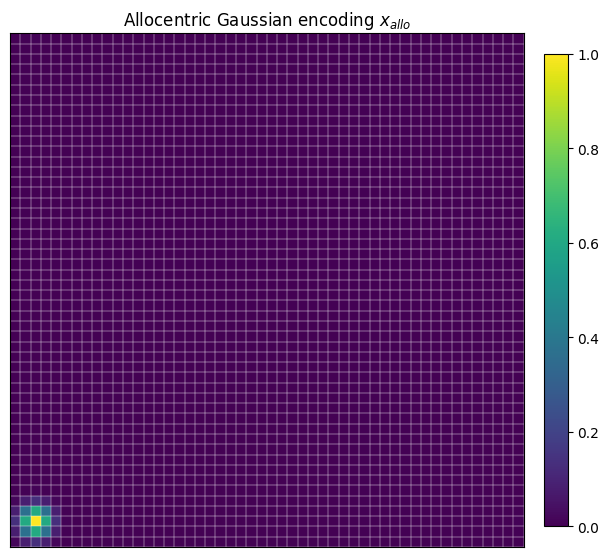

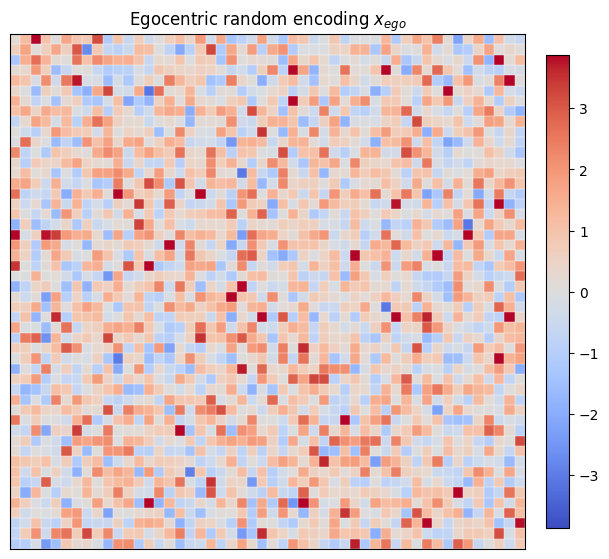

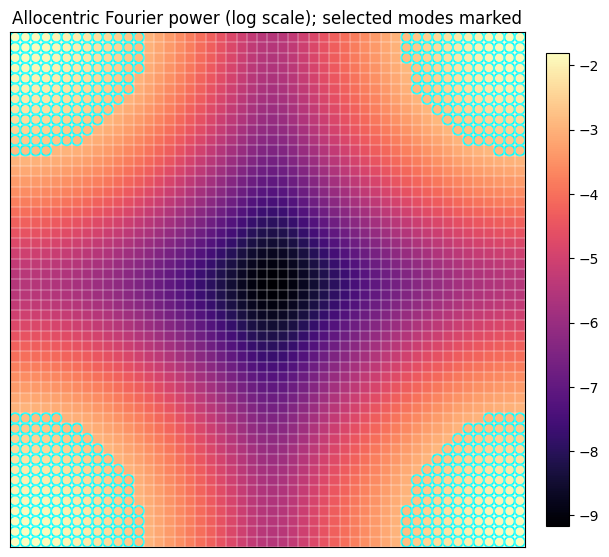

In [5]:
plot_grid_scalar(
    signal_to_grid(G, x_allo),
    title="Allocentric Gaussian encoding $x_{allo}$",
)
plt.show()

x_ego_grid = signal_to_grid(G, x_ego)
ego_scale = np.percentile(np.abs(x_ego_grid), 99)
plot_grid_scalar(
    x_ego_grid,
    title="Egocentric random encoding $x_{ego}$",
    cmap="coolwarm",
    vmin=-ego_scale,
    vmax=ego_scale,
)
plt.show()

power = G.power_spectrum(x_allo)
power_grid = power.reshape(G.p1, G.p2)
ax = plot_grid_scalar(
    np.log10(power_grid + 1e-14),
    title="Allocentric Fourier power (log scale); selected modes marked",
    cmap="magma",
)
selected_frequencies = np.asarray(
    [G.decode(index) for index in params.selected_irrep_indices]
)
ax.scatter(
    selected_frequencies[:, 0],
    selected_frequencies[:, 1],
    s=55,
    marker="o",
    facecolors="none",
    edgecolors="cyan",
    linewidths=1.2,
)
plt.show()

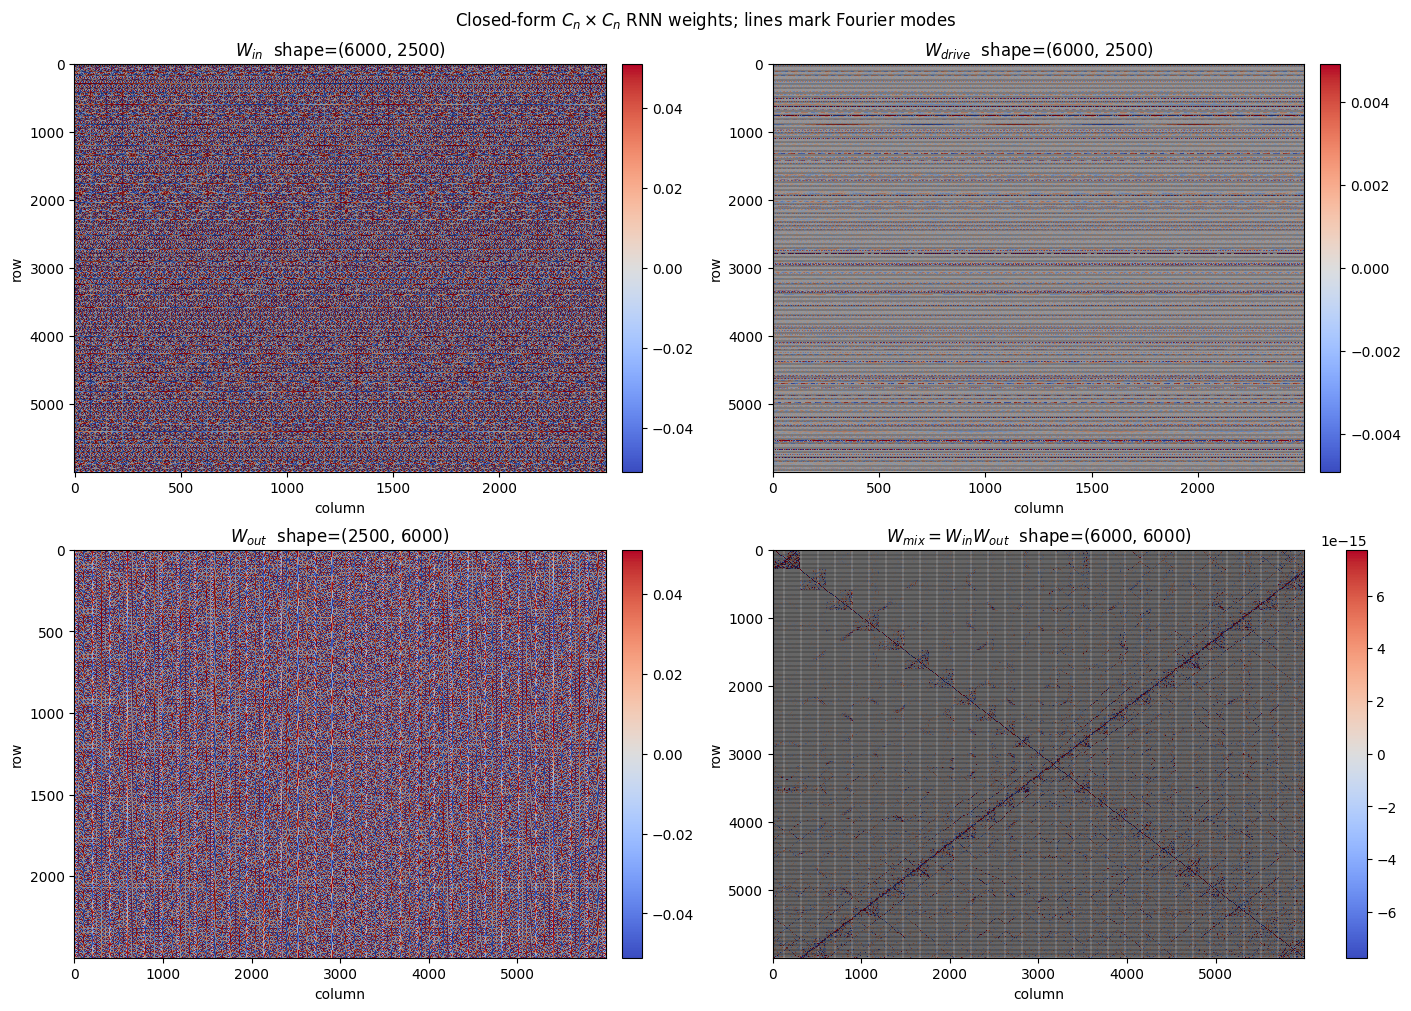

In [6]:
W_mix_for_plot = params.W_in @ params.W_out
weight_matrices = {
    r"$W_{in}$": params.W_in,
    r"$W_{drive}$": params.W_drive,
    r"$W_{out}$": params.W_out,
    r"$W_{mix}=W_{in}W_{out}$": W_mix_for_plot,
}
metadata_irreps = np.asarray([item["irrep_index"] for item in params.metadata])
block_boundaries = np.flatnonzero(np.diff(metadata_irreps)) + 1

figure, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for panel, (ax, (name, matrix)) in enumerate(
    zip(axes.ravel(), weight_matrices.items())
):
    scale = np.percentile(np.abs(matrix), 99)
    image = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        cmap="coolwarm",
        vmin=-scale,
        vmax=scale,
    )
    if panel in (0, 1, 3):
        for boundary in block_boundaries:
            ax.axhline(boundary - 0.5, color="black", linewidth=0.35, alpha=0.7)
    if panel in (2, 3):
        for boundary in block_boundaries:
            ax.axvline(boundary - 0.5, color="black", linewidth=0.35, alpha=0.7)
    ax.set_title(f"{name}  shape={matrix.shape}")
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    figure.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
figure.suptitle("Closed-form $C_n \\times C_n$ RNN weights; lines mark Fourier modes")
plt.show()

del W_mix_for_plot

## 4. Short translation rollouts

We separately report full-signal reconstruction error and decoded-center error. Fourier truncation can preserve the Gaussian peak even when it changes the bump's shape or amplitude.

In [7]:
def summarize_rollout(name, sequence):
    result = rollout(params, x_allo, sequence)
    absolute_errors = np.linalg.norm(
        result["predicted_outputs"] - result["true_outputs"], axis=1
    )
    relative_errors = absolute_errors / np.linalg.norm(
        result["true_outputs"], axis=1
    )
    exact_centers = np.asarray(
        [transformed_center(G, int(state), center_xy) for state in result["cumulative_states"]]
    )
    predicted_centers = np.asarray(
        [decode_spatial_argmax(G, output) for output in result["predicted_outputs"]]
    )
    position_errors = center_errors(G, predicted_centers, exact_centers)
    print(
        f"{name:16s} final relative signal={relative_errors[-1]:.3e}; "
        f"max center={position_errors.max():.3f}"
    )
    return {
        "rollout": result,
        "absolute_errors": absolute_errors,
        "relative_errors": relative_errors,
        "position_errors": position_errors,
        "exact_centers": exact_centers,
        "predicted_centers": predicted_centers,
    }

short_sequences = {
    "x translation": [G.encode(1, 0)] * 6,
    "y translation": [G.encode(0, 1)] * 6,
    "mixed": [
        G.encode(1, 0),
        G.encode(0, 1),
        G.encode(-1, 0),
        G.encode(1, -1),
        G.encode(0, 1),
        G.encode(1, 0),
    ],
}
short_results = {
    name: summarize_rollout(name, sequence)
    for name, sequence in short_sequences.items()
}

x translation    final relative signal=2.868e-01; max center=0.000
y translation    final relative signal=2.868e-01; max center=0.000


mixed            final relative signal=2.868e-01; max center=0.000


## 5. Long momentum rollout

The 250-step bounded random walk uses the same presentation as the discrete-$SE(2)$ experiment: the first relative translation moves the bump near the arena center, subsequent local translations have momentum with occasional turns and stays, and exact and decoded centers are overlaid on a neutral lattice.

long trajectory  final relative signal=2.869e-01; max center=0.000
Long-sequence tracking summary
------------------------------
max output error:    0.5085673790286331
mean output error:   0.5085175563184352
max center error:    0.0
mean center error:   0.0


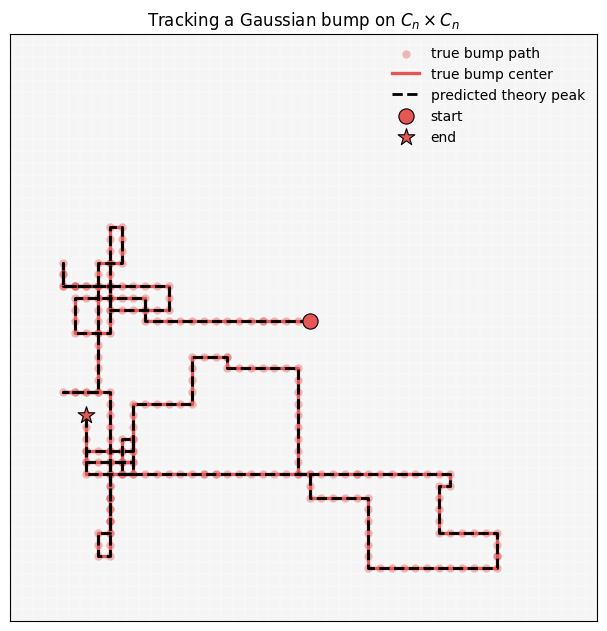

In [8]:
num_long_steps = 250
start_xy = (
    (G.p1 // 2 - center_xy[0]) % G.p1,
    (G.p2 // 2 - center_xy[1]) % G.p2,
)
long_sequence = make_momentum_motion_sequence(
    G,
    steps=num_long_steps,
    seed=1,
    turn_probability=0.18,
    stay_probability=0.04,
    start_xy=start_xy,
)
long = summarize_rollout("long trajectory", long_sequence)

print("Long-sequence tracking summary")
print("------------------------------")
print("max output error:   ", long["absolute_errors"].max())
print("mean output error:  ", long["absolute_errors"].mean())
print("max center error:   ", long["position_errors"].max())
print("mean center error:  ", long["position_errors"].mean())

plot_grid_trajectory(
    G,
    long["exact_centers"],
    long["predicted_centers"],
    title="Tracking a Gaussian bump on $C_n\\times C_n$",
)
plt.show()

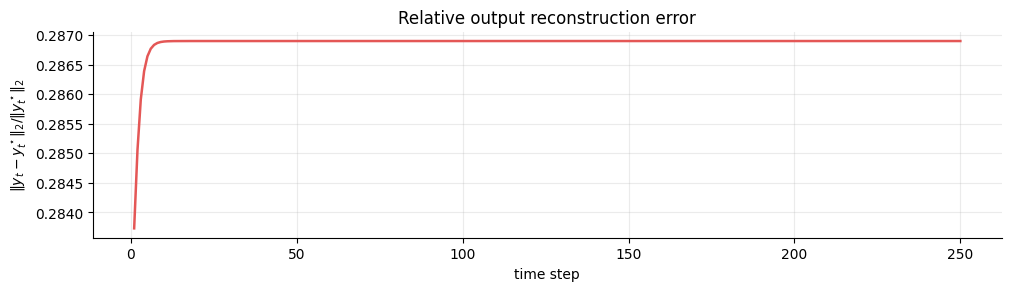

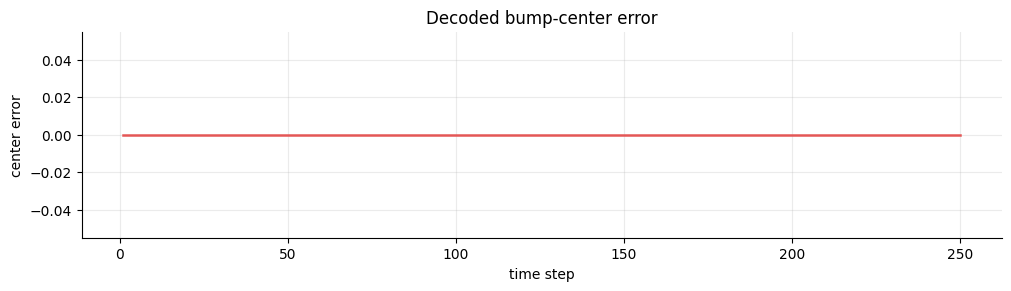

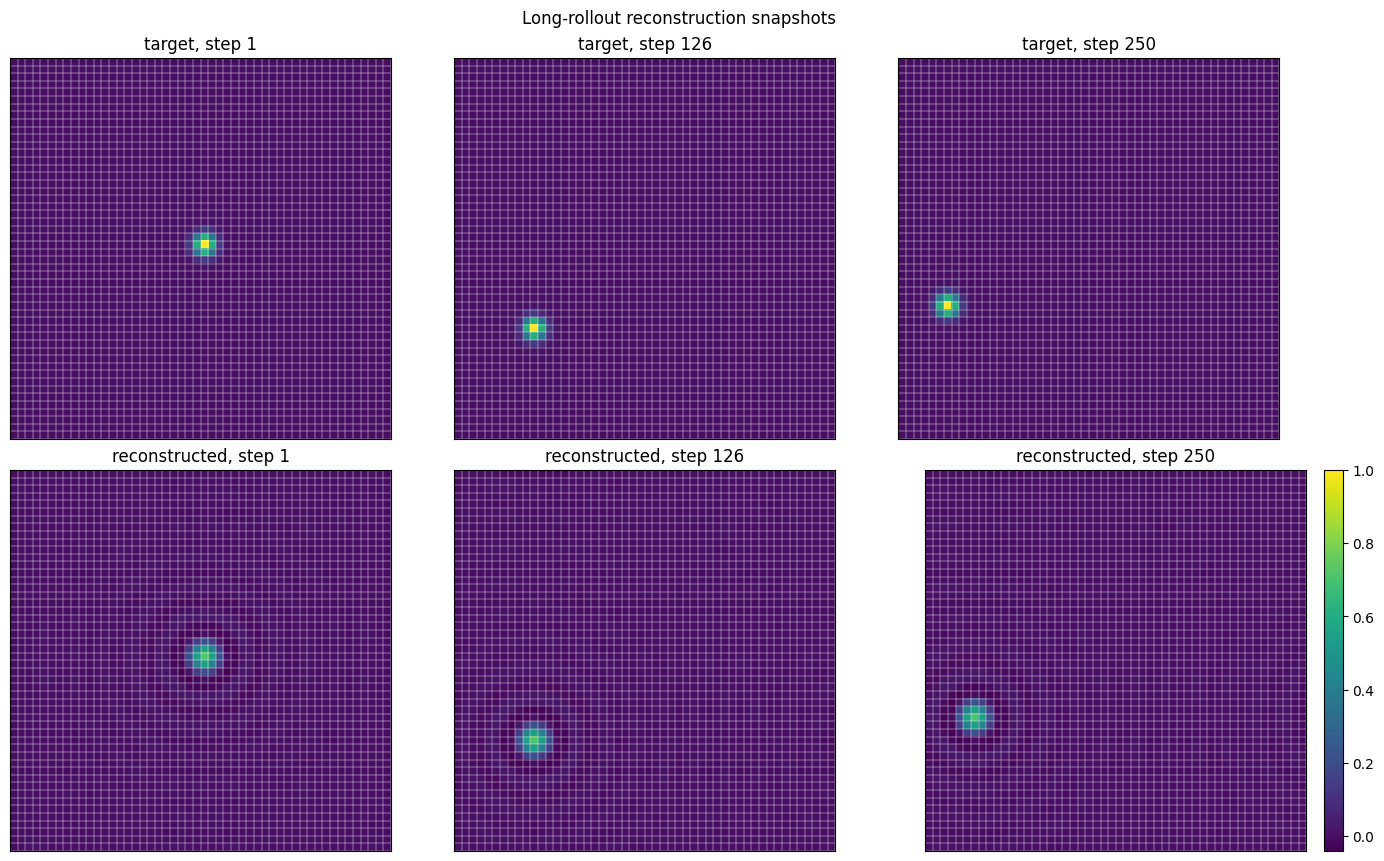

In [9]:
time = np.arange(1, num_long_steps + 1)
for values, ylabel, title in (
    (
        long["relative_errors"],
        r"$\|y_t-y_t^\star\|_2 / \|y_t^\star\|_2$",
        "Relative output reconstruction error",
    ),
    (long["position_errors"], "center error", "Decoded bump-center error"),
):
    figure, ax = plt.subplots(figsize=(10, 2.8), constrained_layout=True)
    ax.plot(time, values, color=TRACK_COLOR, linewidth=1.8)
    ax.set(xlabel="time step", ylabel=ylabel, title=title)
    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.show()

snapshot_steps = [0, num_long_steps // 2, num_long_steps - 1]
figure, axes = plt.subplots(2, 3, figsize=(14, 8.5), constrained_layout=True)
snapshot_values = [
    signal_to_grid(G, long["rollout"][key][step])
    for key in ("true_outputs", "predicted_outputs")
    for step in snapshot_steps
]
vmin = min(float(values.min()) for values in snapshot_values)
vmax = max(float(values.max()) for values in snapshot_values)
for column, step in enumerate(snapshot_steps):
    plot_grid_scalar(
        signal_to_grid(G, long["rollout"]["true_outputs"][step]),
        ax=axes[0, column],
        title=f"target, step {step + 1}",
        vmin=vmin,
        vmax=vmax,
        colorbar=False,
    )
    plot_grid_scalar(
        signal_to_grid(G, long["rollout"]["predicted_outputs"][step]),
        ax=axes[1, column],
        title=f"reconstructed, step {step + 1}",
        vmin=vmin,
        vmax=vmax,
        colorbar=column == 2,
    )
figure.suptitle("Long-rollout reconstruction snapshots")
plt.show()

## 6. Hidden-state tuning

These tuning curves are computed by translating the allocentric input through every group element while holding the egocentric drive fixed at the identity. We show one hidden unit from each distinct nonconstant Fourier mode, up to the visualization limit set in the cell below. Since $C_n\times C_n$ has no orientation coordinate, each tuning curve is already a single square-grid field; no direction alignment or marginalization is needed. Raw activations share one color scale.

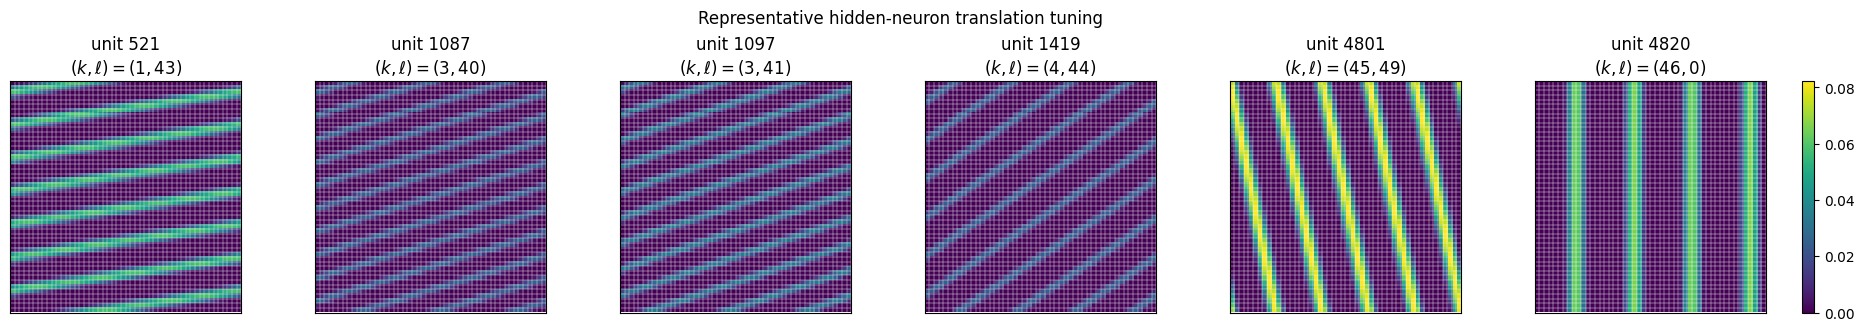

Selected tuning units
---------------------
521 {'irrep_index': 93, 'irrep_name': 'C50xC50|[irrep_1,43]:1', 'irrep_dim': 1, 'eps1': -1, 'eps2': 1, 'delta': 2, 'k0': 0, 'k1': 0, 'k2': 0}
1087 {'irrep_index': 190, 'irrep_name': 'C50xC50|[irrep_3,40]:1', 'irrep_dim': 1, 'eps1': -1, 'eps2': -1, 'delta': 1, 'k0': 0, 'k1': 0, 'k2': 0}
1097 {'irrep_index': 191, 'irrep_name': 'C50xC50|[irrep_3,41]:1', 'irrep_dim': 1, 'eps1': -1, 'eps2': 1, 'delta': 2, 'k0': 0, 'k1': 0, 'k2': 0}
1419 {'irrep_index': 244, 'irrep_name': 'C50xC50|[irrep_4,44]:1', 'irrep_dim': 1, 'eps1': -1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}
4801 {'irrep_index': 2299, 'irrep_name': 'C50xC50|[irrep_45,49]:1', 'irrep_dim': 1, 'eps1': 1, 'eps2': 1, 'delta': 1, 'k0': 0, 'k1': 0, 'k2': 0}
4820 {'irrep_index': 2300, 'irrep_name': 'C50xC50|[irrep_46,0]:1', 'irrep_dim': 1, 'eps1': -1, 'eps2': -1, 'delta': 2, 'k0': 0, 'k1': 0, 'k2': 0}


In [10]:
num_tuning_units_to_plot = 6
tuning_unit_rng = np.random.default_rng(3)

# These tuning curves sweep translated allocentric inputs while holding the
# egocentric drive at the identity.
# Note: a trajectory-based analysis could instead sample movements from the
# data distribution and average each neuron's activity at a given group element
# across trajectories.
tuning_hidden = hidden_tuning_over_group(params, x_allo)
units_by_irrep = {}
for unit, metadata in enumerate(params.metadata):
    irrep_index = metadata["irrep_index"]
    if irrep_index == 0:
        continue
    units_by_irrep.setdefault(irrep_index, []).append(unit)

irrep_indices = np.asarray(list(units_by_irrep))
if len(irrep_indices) > num_tuning_units_to_plot:
    irrep_indices = tuning_unit_rng.choice(
        irrep_indices,
        size=num_tuning_units_to_plot,
        replace=False,
    )
representatives = [
    int(tuning_unit_rng.choice(units_by_irrep[int(irrep_index)]))
    for irrep_index in sorted(irrep_indices)
]

tuning_fields = [signal_to_grid(G, tuning_hidden[:, unit]) for unit in representatives]
vmin = min(float(field.min()) for field in tuning_fields)
vmax = max(float(field.max()) for field in tuning_fields)
figure, axes = plt.subplots(
    1,
    len(representatives),
    figsize=(3.2 * len(representatives), 3.2),
    constrained_layout=True,
)
axes = np.atleast_1d(axes)
for ax, unit, field in zip(axes, representatives, tuning_fields):
    irrep_index = params.metadata[unit]["irrep_index"]
    frequency = G.decode(irrep_index)
    plot_grid_scalar(
        field,
        ax=ax,
        title=(f"unit {unit}\n" rf"$(k,\ell)={frequency}$"),
        vmin=vmin,
        vmax=vmax,
        colorbar=False,
    )
colorbar = plt.cm.ScalarMappable(
    norm=plt.Normalize(vmin=vmin, vmax=vmax),
    cmap=plt.get_cmap("viridis"),
)
colorbar.set_array([])
figure.colorbar(colorbar, ax=axes, fraction=0.025, pad=0.02)
figure.suptitle("Representative hidden-neuron translation tuning")
plt.show()

print("Selected tuning units")
print("---------------------")
for unit in representatives:
    print(unit, params.metadata[unit])

In [11]:
retained_fraction = power[params.selected_irrep_indices].sum() / power.sum()
all_width = sum(hidden_width(irrep) for irrep in all_irreps)
print(f"retained Fourier power: {retained_fraction:.2%}")
print(f"selected hidden width: {params.hidden_dim:,}")
print(f"all-irrep hidden width: {all_width:,}")
print(f"width reduction: {1 - params.hidden_dim / all_width:.2%}")

retained Fourier power: 91.89%
selected hidden width: 6,000
all-irrep hidden width: 30,000
width reduction: 80.00%


## 7. Module-restricted neural manifolds

For each available conjugate Fourier pair, we form the population orbit

$$
\mathcal M_{\rho,x_{\mathrm{allo}}}
=
\{\Pi_\rho\Phi(g\cdot x_{\mathrm{allo}}):g\in C_n\times C_n\}.
$$

We use a stratified $12\times12$ sample of the $50^2$ translations and iterate every sampled population state to a recurrent fixed point. The final residual is reported explicitly. Conjugate characters are combined so complex Fourier phases are represented in real population coordinates.

A single conjugate Fourier pair retains one phase and therefore generally produces a circle, not a two-torus. We plot six high-variance representative modules. As a positive control, we also combine two modules with independent frequency vectors; that joint representation can retain both translation phases and recover $\mathbb T^2$. UMAP is used only for visualization. Vietoris–Rips persistent homology is computed after PCA in neural space.

identity-update fixed-point iteration: converged=True, iterations=21, max residual=6.783e-09


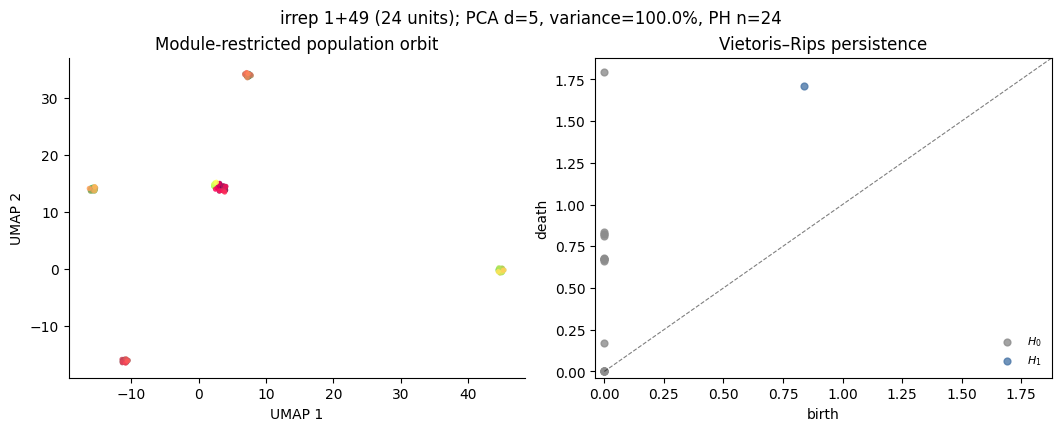

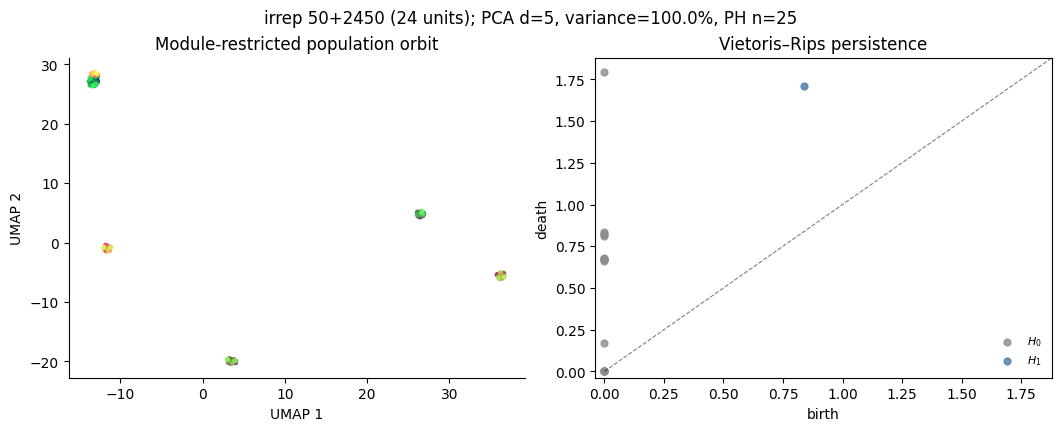

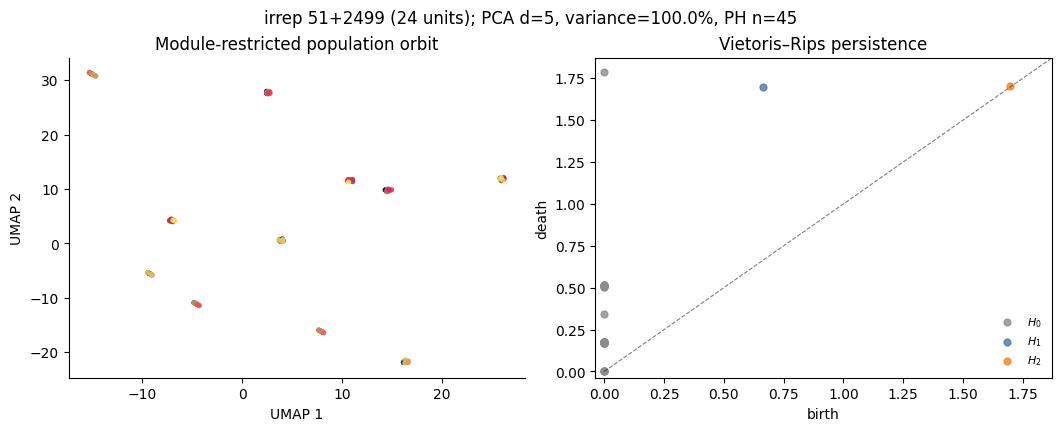

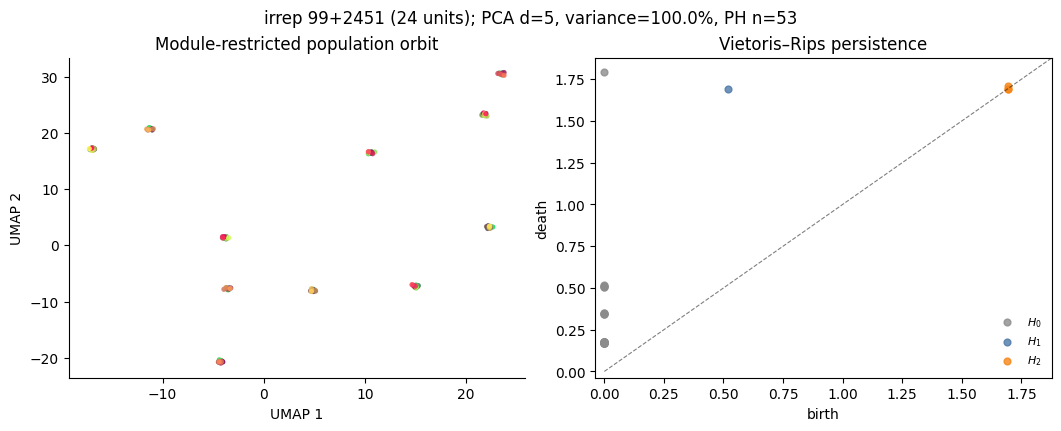

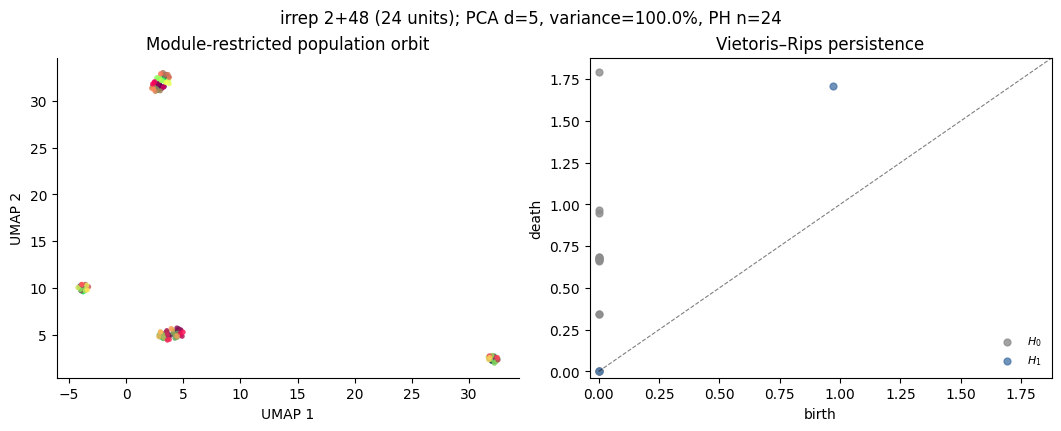

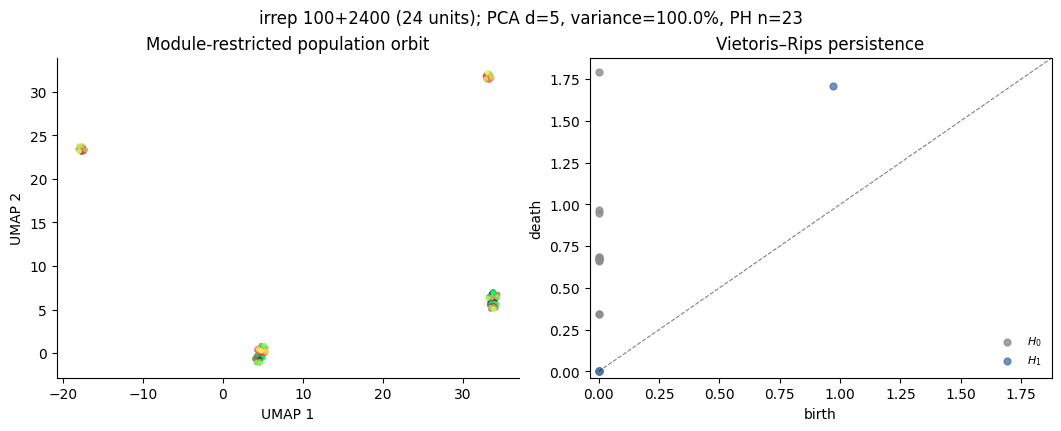

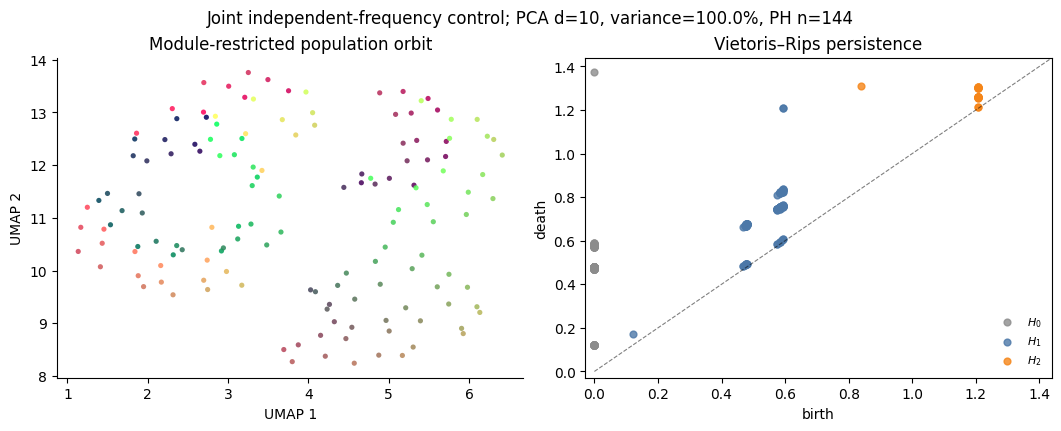

In [12]:
sample_coordinates_1d = np.unique(
    np.linspace(0, G.p1 - 1, 12, dtype=int)
)
translation_coordinates = np.asarray(
    [(x, y) for x in sample_coordinates_1d for y in sample_coordinates_1d]
)
translation_elements = np.asarray(
    [G.encode(int(x), int(y)) for x, y in translation_coordinates]
)
translation_fixed = fixed_point_embedding(
    params,
    tuning_hidden[translation_elements],
    tolerance=1e-8,
    max_iterations=50,
)
print(
    "identity-update fixed-point iteration: "
    f"converged={translation_fixed.converged}, "
    f"iterations={translation_fixed.iterations}, "
    f"max residual={translation_fixed.residuals.max():.3e}"
)

all_module_orbits = build_module_orbits(params, translation_fixed.states)
module_scores = np.asarray(
    [np.mean(np.var(module.activity, axis=0)) for module in all_module_orbits]
)
representative_module_indices = np.argsort(module_scores)[::-1][:6]
manifold_modules = [
    all_module_orbits[index] for index in representative_module_indices
]

independent_pair = None
for first_index, first_module in enumerate(all_module_orbits):
    first_frequency = G.decode(first_module.irrep_indices[0])
    for second_module in all_module_orbits[first_index + 1 :]:
        second_frequency = G.decode(second_module.irrep_indices[0])
        determinant = (
            first_frequency[0] * second_frequency[1]
            - first_frequency[1] * second_frequency[0]
        )
        if np.gcd(abs(determinant), G.p1) == 1:
            independent_pair = (first_module, second_module)
            break
    if independent_pair is not None:
        break
if independent_pair is not None:
    manifold_modules.append(combine_module_orbits(list(independent_pair)))

manifold_colors = coordinate_colors(
    translation_coordinates,
    (G.p1, G.p2),
)
manifold_analyses = analyze_module_orbits(
    manifold_modules,
    max_persistence_points=len(translation_coordinates),
    max_homology_dimension=2,
    random_state=7,
)

for index, analysis in enumerate(manifold_analyses):
    is_joint_control = index == len(manifold_analyses) - 1 and independent_pair is not None
    title = (
        "Joint independent-frequency control"
        if is_joint_control
        else analysis.module.label
    )
    plot_manifold_analysis(analysis, manifold_colors, title=title)
    plt.show()

## 8. Conclusions and limitations

- The small all-irrep model reproduces the regular action of $C_n\times C_n$ to floating-point precision.
- The $n=50$ experiment retains 500 Fourier characters selected by allocentric Fourier power and is therefore approximate; signal reconstruction and decoded-center errors measure different consequences of truncation.
- The theorem's width contribution $4q_\rho d_\rho^3$ reduces to $12$ units per selected mode because `q_rho=3` and every $C_n\times C_n$ irrep has $d_\rho=1$.
- Module-restricted manifold topology is representation-dependent: one conjugate Fourier pair generally exposes a circle, while two independent pairs can expose the full translation torus.
- UMAP is only a display coordinate system. Persistent homology is computed in PCA-reduced neural space, and its result remains sensitive to sampling and filtration scale.
- The square-grid encoding, trajectory, and tuning plots are direct two-dimensional views. No orientation alignment or higher-dimensional projection is required.
- The group is abelian: this notebook tests translation accumulation, but not the noncommuting translation–rotation interactions that distinguish discrete $SE(2)$.